### 신경계 (ATC 코드 N계열)
- 아세트아미노펜 / 파라세타몰 단일제

In [1]:
!pip install scipy -q
!apt-get install -y fonts-nanum -q > /dev/null

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
from matplotlib_venn import venn2

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 및 B그룹(아세트아미노펜/파라세타몰 단일제) 마스크 구성
df = pd.read_csv('/content/FDA_adverse_events_final.csv')
N_total = len(df)

n_group_mask = df['WHO_ATC'].astype(str).str.startswith('N')
n_total = n_group_mask.sum()

sd = df['suspect_drug'].astype(str)
has_aspirin = sd.str.contains('ASPIRIN|ACETYLSALICYLIC', case=False, na=False)
has_acet = sd.str.contains('ACETAMINOPHEN|PARACETAMOL', case=False, na=False)
has_caffeine = sd.str.contains('CAFFEINE', case=False, na=False)
has_nicotine = sd.str.contains('NICOTINE', case=False, na=False)
has_lidocaine = sd.str.contains('LIDOCAINE|BENZOCAINE', case=False, na=False)
has_other_combo = sd.str.contains('GUAIFENESIN|PHENYLEPHRINE', case=False, na=False)

b_mask = n_group_mask & has_acet & ~has_aspirin & ~has_caffeine & ~has_nicotine & ~has_lidocaine & ~has_other_combo
rest_of_n_mask = n_group_mask & (~b_mask)

b_df = df[b_mask].copy()
serious_df = b_df[b_df['serious'] == 'Yes'].copy()

rl = (serious_df['reactions'].astype(str).str.split(';')
      .apply(lambda l: [x.strip() for x in l if x.strip() and x.strip().lower() != 'unknown']))
tmp = pd.DataFrame({'report_id': serious_df['report_id'].values, 'reaction_list': rl.values})
serious_ex = tmp.explode('reaction_list').dropna(subset=['reaction_list'])

liver_keywords = ['hepat', 'liver', 'bilirubin', 'transaminase', 'jaundice', 'coagulable', 'encephalopathy']
overdose_keywords = ['overdose', 'poisoning', 'drug level increased', 'suicide', 'drug abuse', 'toxicity to various agents']
kidney_keywords = ['renal', 'kidney', 'nephro']

# PRR/ROR + FDR 다중비교 보정 + Evans criteria 신호판정 함수
def calc_prr_ror(target_mask, df_all, min_count=3, exclude_terms=None):
    n_d = target_mask.sum()
    n_o = len(df_all) - n_d
    rl = (df_all['reactions'].astype(str).str.split(';')
          .apply(lambda l: [x.strip() for x in l if x.strip() and x.strip().lower() != 'unknown']))
    tmp = pd.DataFrame({'report_id': df_all['report_id'], 'is_target': target_mask.values, 'reaction_list': rl.values})
    ex = tmp.explode('reaction_list').dropna(subset=['reaction_list'])
    ex = ex.drop_duplicates(subset=['report_id', 'reaction_list'])
    if exclude_terms:
        ex = ex[~ex['reaction_list'].isin(exclude_terms)]

    res = []
    for reaction, grp in ex.groupby('reaction_list'):
        a = grp['is_target'].sum(); rt = len(grp); c = rt - a; b = n_d - a; d = n_o - c
        if a < min_count or n_d == 0:
            continue
        _, p_value = stats.fisher_exact([[a, b], [c, d]])
        if min(a, b, c, d) == 0:
            a_, b_, c_, d_ = a + .5, b + .5, c + .5, d + .5
        else:
            a_, b_, c_, d_ = a, b, c, d
        prr = (a_ / (a_ + b_)) / (c_ / (c_ + d_))
        ror = (a_ * d_) / (b_ * c_)
        se = np.sqrt(1/a_ + 1/b_ + 1/c_ + 1/d_)
        res.append({
            'reaction': reaction, 'a': a, 'b': b, 'c': c, 'd': d,
            'PRR': round(prr, 2), 'ROR': round(ror, 2),
            'ROR_CI_low': round(np.exp(np.log(ror) - 1.96*se), 2),
            'ROR_CI_high': round(np.exp(np.log(ror) + 1.96*se), 2),
            'p_value': p_value,
        })
    if not res:
        return pd.DataFrame(columns=['reaction','a','b','c','d','PRR','ROR','ROR_CI_low','ROR_CI_high','p_value'])
    out = pd.DataFrame(res).sort_values('PRR', ascending=False).reset_index(drop=True)
    out['p_adj_fdr'] = multipletests(out['p_value'], method='fdr_bh')[1]
    out['is_signal'] = (out['PRR'] >= 2) & (out['ROR_CI_low'] > 1) & (out['a'] >= 3) & (out['p_adj_fdr'] < 0.05)
    return out

n_only = df[df['WHO_ATC'] == 'N'].copy()
n_target_mask = pd.Series(n_only.index.isin(df[b_mask].index), index=n_only.index)
res_b = calc_prr_ror(n_target_mask, n_only, min_count=10)

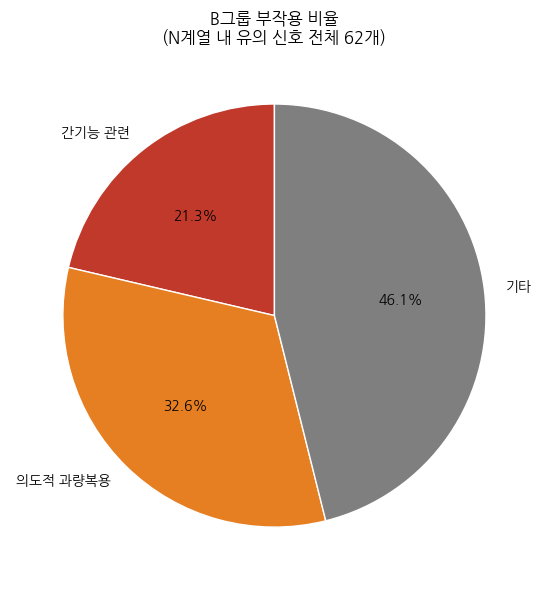

In [2]:
# B그룹 부작용 유형 분류 (간기능/과량복용/기타) 비율 - 유의 신호 전체
def classify_reaction(reaction):
    r = reaction.lower()
    if any(kw in r for kw in liver_keywords):
        return '간기능 관련'
    elif any(kw in r for kw in overdose_keywords):
        return '의도적 과량복용'
    else:
        return '기타'

signal_df = res_b[res_b['is_signal']].copy()
signal_df['category'] = signal_df['reaction'].apply(classify_reaction)

cat_counts = signal_df.groupby('category')['a'].sum()
ordered = ['간기능 관련', '의도적 과량복용', '기타']
colors_map = {'간기능 관련': '#c0392b', '의도적 과량복용': '#e67e22', '기타': '#7f7f7f'}
values = [cat_counts.get(c, 0) for c in ordered]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(values, labels=ordered, colors=[colors_map[c] for c in ordered],
       autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
ax.set_title(f'B그룹 부작용 비율\n(N계열 내 유의 신호 전체 {len(signal_df)}개)')
plt.tight_layout()
plt.show()

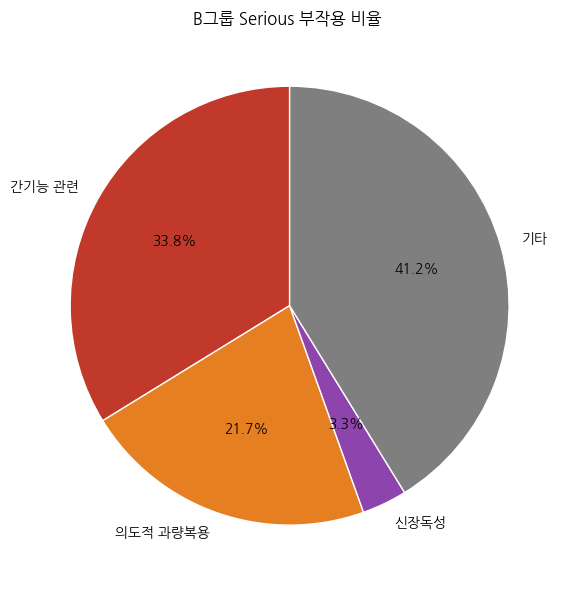

In [3]:
# B그룹 Serious 부작용 유형 분류 (간기능 > 과량복용 > 신장독성 > 기타 우선순위)
def classify_reaction_serious(reaction):
    r = reaction.lower()
    if any(kw in r for kw in liver_keywords):
        return '간기능 관련'
    elif any(kw in r for kw in overdose_keywords):
        return '의도적 과량복용'
    elif any(kw in r for kw in kidney_keywords):
        return '신장독성'
    else:
        return '기타'

serious_ex['category'] = serious_ex['reaction_list'].apply(classify_reaction_serious)

def resolve_category(cats):
    if '간기능 관련' in cats.values:
        return '간기능 관련'
    elif '의도적 과량복용' in cats.values:
        return '의도적 과량복용'
    elif '신장독성' in cats.values:
        return '신장독성'
    else:
        return '기타'

report_cat = serious_ex.groupby('report_id')['category'].apply(resolve_category)
counts = report_cat.value_counts()
ordered = ['간기능 관련', '의도적 과량복용', '신장독성', '기타']
colors_map = {'간기능 관련': '#c0392b', '의도적 과량복용': '#e67e22', '신장독성': '#8e44ad', '기타': '#7f7f7f'}
values = [counts.get(c, 0) for c in ordered]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(values, labels=ordered, colors=[colors_map[c] for c in ordered],
       autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
ax.set_title(f'B그룹 Serious 부작용 비율 ')
plt.tight_layout()
plt.show()

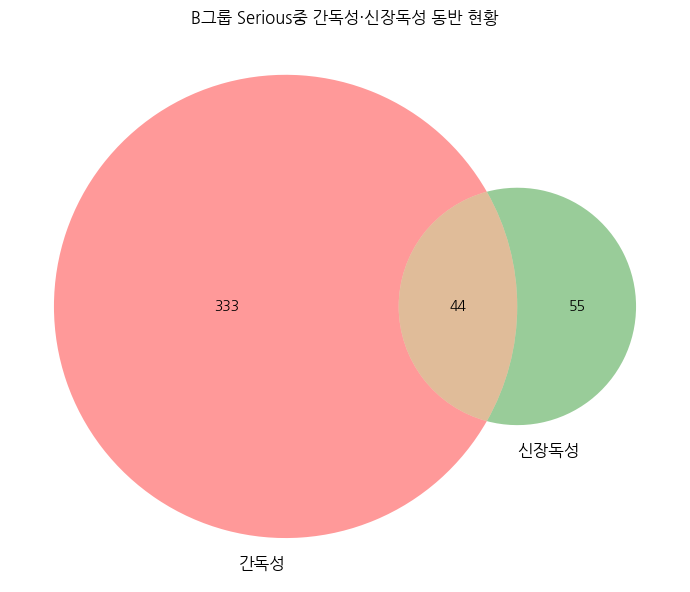

In [4]:
# B그룹 Serious 중 간독성·신장독성 동반 현황 (벤 다이어그램)
fig, ax = plt.subplots(figsize=(7, 7))
venn2(subsets=(333, 55, 44), set_labels=('간독성', '신장독성'), ax=ax)
ax.set_title(f'B그룹 Serious중 간독성·신장독성 동반 현황')
plt.tight_layout()
plt.show()

In [5]:
# 간독성 x 신장독성 2x2 통계검정 (위 벤다이어그램 수치 기준)
a = 44    # 간독성 O & 신장독성 O
b = 333   # 간독성 O & 신장독성 X
c = 55    # 간독성 X & 신장독성 O
d = 684   # 간독성 X & 신장독성 X

odds_fisher, p_value = stats.fisher_exact([[a, b], [c, d]])
OR = (a * d) / (b * c)
se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
ci_low = np.exp(np.log(OR) - 1.96 * se_log_or)
ci_high = np.exp(np.log(OR) + 1.96 * se_log_or)

print(f"Odds Ratio: {OR:.2f} (95% CI: {ci_low:.2f} ~ {ci_high:.2f})")
print(f"Fisher's exact test p-value: {p_value:.6f}")

chi2, p_chi, dof, expected = stats.chi2_contingency([[a, b], [c, d]])
print(f"Chi-square: {chi2:.2f}, p-value: {p_chi:.6f}")

Odds Ratio: 1.64 (95% CI: 1.08 ~ 2.49)
Fisher's exact test p-value: 0.025499
Chi-square: 5.01, p-value: 0.025184


In [6]:
# 아세트아미노펜군 vs N계열 나머지: 간독성 반응 비율 (ROR)
n_only['is_liver'] = n_only['reactions'].astype(str).str.lower().apply(
    lambda r: any(kw in r for kw in liver_keywords))

n_d_correct = n_target_mask.sum()
n_o_correct = len(n_only) - n_d_correct

a = n_only.loc[n_target_mask, 'is_liver'].sum()
b = n_d_correct - a
c = n_only.loc[~n_target_mask, 'is_liver'].sum()
d = n_o_correct - c

_, p = stats.fisher_exact([[a, b], [c, d]])
OR = (a*d) / (b*c)
se = np.sqrt(1/a + 1/b + 1/c + 1/d)
ci_low = np.exp(np.log(OR) - 1.96*se)
ci_high = np.exp(np.log(OR) + 1.96*se)

print(f"아세트아미노펜군 간독성 비율: {a/n_d_correct*100:.1f}% (n={a}/{n_d_correct})")
print(f"N계열 나머지 간독성 비율: {c/n_o_correct*100:.1f}% (n={c}/{n_o_correct})")
print(f"ROR: {OR:.2f} (95% CI {ci_low:.2f}~{ci_high:.2f})")
print(f"Fisher's exact p-value: {p:.2e}")

아세트아미노펜군 간독성 비율: 28.5% (n=379/1331)
N계열 나머지 간독성 비율: 2.8% (n=84/2993)
ROR: 13.79 (95% CI 10.76~17.66)
Fisher's exact p-value: 1.75e-129


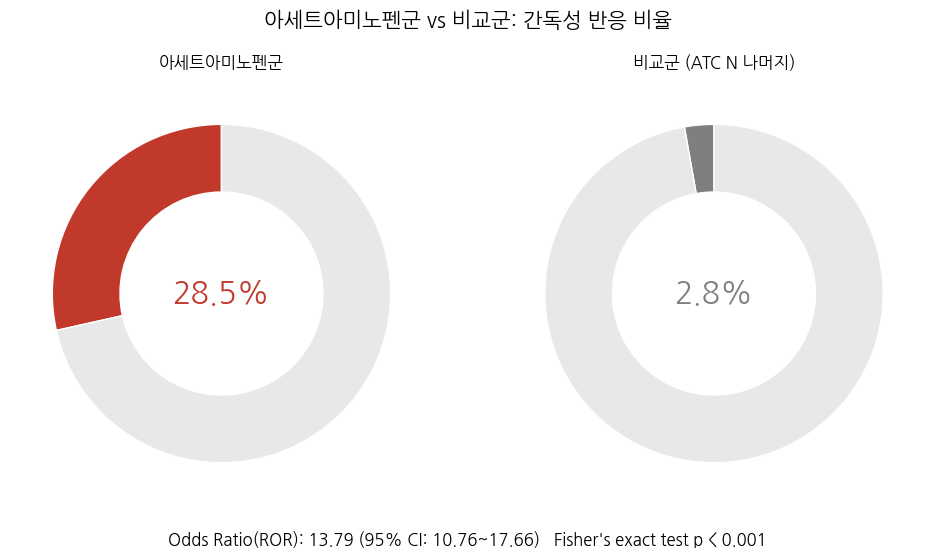

In [7]:
# 위 결과를 도넛 차트로 시각화 (수치는 앞 셀 계산값 그대로)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
groups = [
    ('아세트아미노펜군', 28.5, '#c0392b'),
    ('비교군 (ATC N 나머지)', 2.8, '#7f7f7f')
]
for ax, (label, pct, color) in zip(axes, groups):
    ax.pie([pct, 100-pct], colors=[color, '#e8e8e8'], startangle=90,
           wedgeprops={'width': 0.4, 'edgecolor': 'white'})
    ax.text(0, 0, f'{pct}%', ha='center', va='center', fontsize=22, fontweight='bold', color=color)
    ax.set_title(label, fontsize=12, pad=10)

fig.suptitle('아세트아미노펜군 vs 비교군: 간독성 반응 비율', fontsize=15, y=1.02)
fig.text(0.5, -0.05,
         "Odds Ratio(ROR): 13.79 (95% CI: 10.76~17.66)   Fisher's exact test p < 0.001",
         ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# 중증도 세부 항목 비교: B그룹 vs 전체 df
sev_cols = ['is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling']
n_d = b_mask.sum()
n_o = len(df) - n_d

results = []
for col in sev_cols:
    a = df.loc[b_mask, col].sum()
    b = n_d - a
    c = df.loc[~b_mask, col].sum()
    d = n_o - c

    _, p = stats.fisher_exact([[a, b], [c, d]])
    if min(a, b, c, d) == 0:
        a_, b_, c_, d_ = a+.5, b+.5, c+.5, d+.5
    else:
        a_, b_, c_, d_ = a, b, c, d
    OR = (a_*d_) / (b_*c_)
    se = np.sqrt(1/a_ + 1/b_ + 1/c_ + 1/d_)
    ci_low = np.exp(np.log(OR) - 1.96*se)
    ci_high = np.exp(np.log(OR) + 1.96*se)

    results.append({
        'severity': col, 'B그룹%': round(a/n_d*100,1), '전체%': round(c/n_o*100,1),
        'OR': round(OR,2), 'CI_low': round(ci_low,2), 'CI_high': round(ci_high,2),
        'p_value': p
    })

sev_result = pd.DataFrame(results)
print(sev_result.to_string(index=False))

       severity  B그룹%  전체%   OR  CI_low  CI_high      p_value
       is_fatal  17.6 14.2 1.29    1.11     1.50 8.875297e-04
is_hospitalized  54.2 32.8 2.43    2.17     2.72 1.287932e-53
 is_life_threat  15.7  4.7 3.74    3.18     4.41 6.873708e-46
   is_disabling   2.0  3.2 0.62    0.42     0.92 1.410004e-02


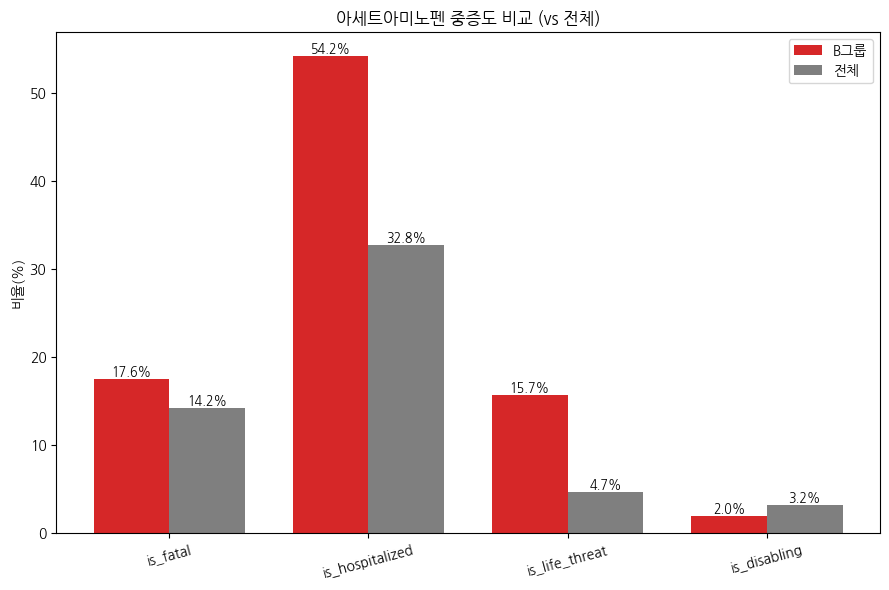

In [9]:
# 중증도 비교 시각화 (위 sev_result 사용)
x = np.arange(len(sev_result))
fig, ax = plt.subplots(figsize=(9, 6))
b1 = ax.bar(x - 0.19, sev_result['B그룹%'], 0.38, label='B그룹', color='#d62728')
b2 = ax.bar(x + 0.19, sev_result['전체%'], 0.38, label='전체', color='#7f7f7f')
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}%', (bar.get_x() + bar.get_width()/2, h), ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(sev_result['severity'], rotation=15)
ax.set_ylabel('비율(%)')
ax.set_title('아세트아미노펜 중증도 비교 (vs 전체)')
ax.legend()
plt.tight_layout()
plt.show()

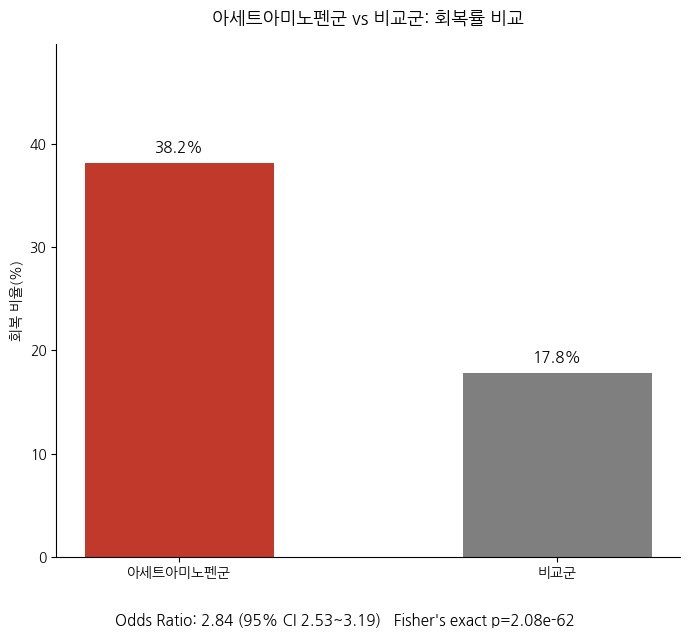

In [10]:
# 회복률 비교: 아세트아미노펜군 vs 비교군
n_d = b_mask.sum()
n_o = len(df) - n_d

a = df.loc[b_mask, 'patient_recovered'].sum()
b = n_d - a
c = df.loc[~b_mask, 'patient_recovered'].sum()
d = n_o - c

_, p = stats.fisher_exact([[a, b], [c, d]])
OR = (a*d) / (b*c)
se = np.sqrt(1/a + 1/b + 1/c + 1/d)
ci_low = np.exp(np.log(OR) - 1.96*se)
ci_high = np.exp(np.log(OR) + 1.96*se)

groups1 = ['아세트아미노펜군', '비교군']
pct1 = [a/n_d*100, c/n_o*100]

fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(groups1, pct1, color=['#c0392b', '#7f7f7f'], width=0.5)
for bar, pct, n in zip(bars, pct1, [a, c]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pct:.1f}%', ha='center', fontsize=11)

ax.set_ylabel('회복 비율(%)')
ax.set_ylim(0, max(pct1) * 1.3)
ax.set_title('아세트아미노펜군 vs 비교군: 회복률 비교', fontsize=13, pad=15)
ax.spines[['top', 'right']].set_visible(False)

plt.figtext(0.5, -0.05,
            f'Odds Ratio: {OR:.2f} (95% CI {ci_low:.2f}~{ci_high:.2f})   Fisher\'s exact p={p:.2e}',
            ha='center', fontsize=11)
plt.tight_layout()
plt.show()

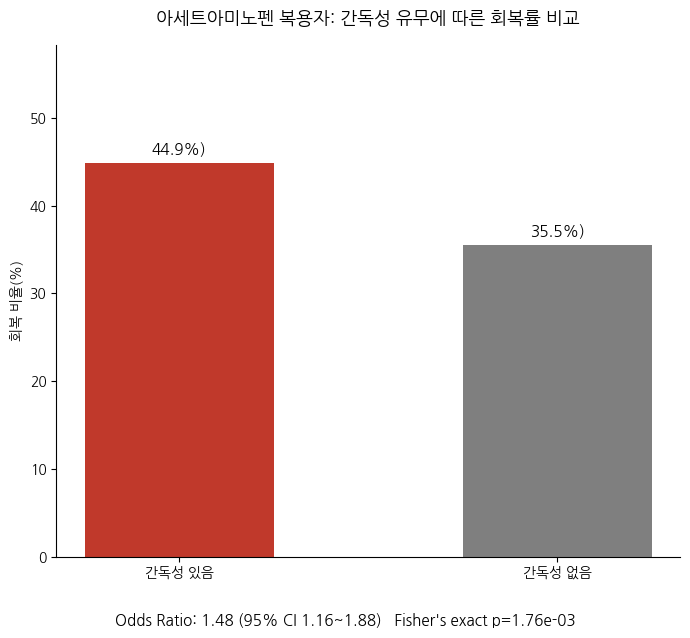

In [11]:
# 아세트아미노펜 복용자 내: 간독성 유무에 따른 회복률 비교
b_df['is_liver'] = b_df['reactions'].astype(str).str.lower().apply(
    lambda r: any(kw in r for kw in liver_keywords))

a2 = b_df.loc[b_df['is_liver'], 'patient_recovered'].sum()
b2 = b_df['is_liver'].sum() - a2
c2 = b_df.loc[~b_df['is_liver'], 'patient_recovered'].sum()
d2 = (~b_df['is_liver']).sum() - c2

_, p2 = stats.fisher_exact([[a2, b2], [c2, d2]])
OR2 = (a2*d2) / (b2*c2)
se2 = np.sqrt(1/a2 + 1/b2 + 1/c2 + 1/d2)
ci_low2 = np.exp(np.log(OR2) - 1.96*se2)
ci_high2 = np.exp(np.log(OR2) + 1.96*se2)
groups2 = ['간독성 있음', '간독성 없음']
pct2 = [a2/(a2+b2)*100, c2/(c2+d2)*100]

fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(groups2, pct2, color=['#c0392b', '#7f7f7f'], width=0.5)
for bar, pct, n in zip(bars, pct2, [a2, c2]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pct:.1f}%)', ha='center', fontsize=11)

ax.set_ylabel('회복 비율(%)')
ax.set_ylim(0, max(pct2) * 1.3)
ax.set_title('아세트아미노펜 복용자: 간독성 유무에 따른 회복률 비교', fontsize=13, pad=15)
ax.spines[['top', 'right']].set_visible(False)

plt.figtext(0.5, -0.05,
            f'Odds Ratio: {OR2:.2f} (95% CI {ci_low2:.2f}~{ci_high2:.2f})   Fisher\'s exact p={p2:.2e}',
            ha='center', fontsize=11)
plt.tight_layout()
plt.show()

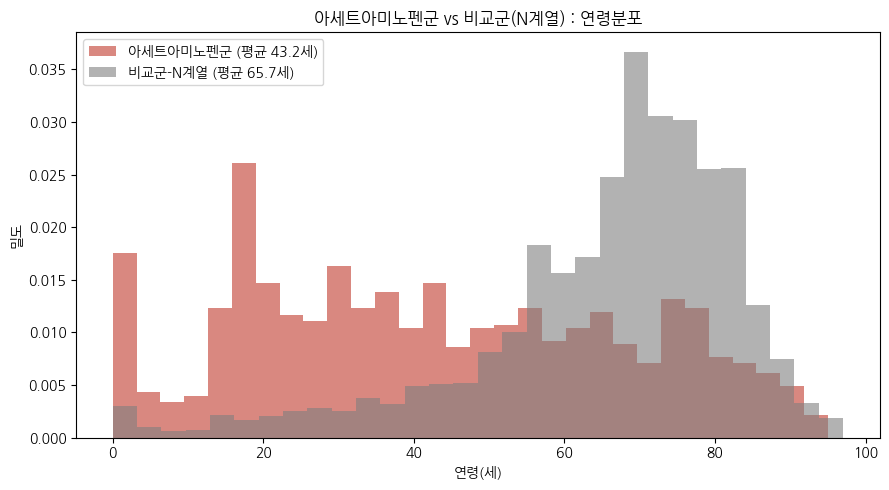

In [12]:
# 연령 분포: 아세트아미노펜군 vs 비교군(N계열)
age_b = pd.to_numeric(n_only.loc[n_target_mask, 'patient_age_years'], errors='coerce').dropna()
age_o = pd.to_numeric(n_only.loc[~n_target_mask, 'patient_age_years'], errors='coerce').dropna()
_, p_age = stats.mannwhitneyu(age_b, age_o)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(age_b, bins=30, alpha=0.6, color='#c0392b', label=f'아세트아미노펜군 (평균 {age_b.mean():.1f}세)', density=True)
ax.hist(age_o, bins=30, alpha=0.6, color='#7f7f7f', label=f'비교군-N계열 (평균 {age_o.mean():.1f}세)', density=True)
ax.set_xlabel('연령(세)')
ax.set_ylabel('밀도')
ax.set_title(f'아세트아미노펜군 vs 비교군(N계열) : 연령분포')
ax.legend()
plt.tight_layout()
plt.show()

  age_group  B그룹%  n_B  비교군%  n_비교군
0      0-20  33.6  238   6.4     78
1     21-40  38.9  265  16.1    143
2     41-60  31.0  226   3.8    479
3     61-80  18.1  216   1.4   1333
4       81+  14.5   83   0.2    401


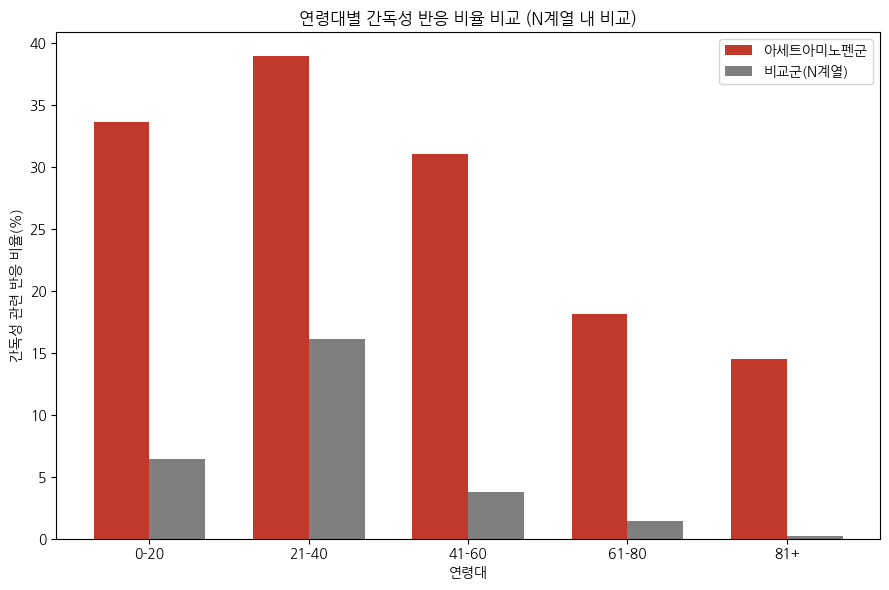

In [13]:
# 연령대별 간독성 반응 비율 비교 (N계열 내 층화)
n_only['age_num'] = pd.to_numeric(n_only['patient_age_years'], errors='coerce')
n_only['age_group2'] = pd.cut(n_only['age_num'], bins=[0,20,40,60,80,120],
                               labels=['0-20','21-40','41-60','61-80','81+'])

rows = []
for ag in ['0-20','21-40','41-60','61-80','81+']:
    sub_b = n_only[(n_only['age_group2']==ag) & n_target_mask]
    sub_o = n_only[(n_only['age_group2']==ag) & (~n_target_mask)]
    if len(sub_b) < 5 or len(sub_o) < 5:
        continue
    a_ag = sub_b['is_liver'].sum(); n_b_ag = len(sub_b)
    c_ag = sub_o['is_liver'].sum(); n_o_ag = len(sub_o)
    rows.append({'age_group': ag, 'B그룹%': round(a_ag/n_b_ag*100,1), 'n_B': n_b_ag,
                 '비교군%': round(c_ag/n_o_ag*100,1), 'n_비교군': n_o_ag})

age_strat = pd.DataFrame(rows)
print(age_strat)

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(age_strat))
width = 0.35
ax.bar(x - width/2, age_strat['B그룹%'], width, label='아세트아미노펜군', color='#c0392b')
ax.bar(x + width/2, age_strat['비교군%'], width, label='비교군(N계열)', color='#7f7f7f')
ax.set_xticks(x)
ax.set_xticklabels(age_strat['age_group'])
ax.set_xlabel('연령대')
ax.set_ylabel('간독성 관련 반응 비율(%)')
ax.set_title('연령대별 간독성 반응 비율 비교 (N계열 내 비교)')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# 다변량 로지스틱 회귀: 간독성 발생 (연령·성별·병용약물 수 통제)
n_only['is_target'] = n_target_mask.astype(int)
n_only['sex_female'] = (n_only['patient_sex'] == 'Female').astype(int)

model_data2 = n_only[['is_liver', 'is_target', 'age_num', 'sex_female', 'num_drugs']].dropna().copy()
model_data2['is_liver'] = model_data2['is_liver'].astype(int)
model2 = smf.logit('is_liver ~ is_target + age_num + sex_female + num_drugs', data=model_data2).fit()

Optimization terminated successfully.
         Current function value: 0.257439
         Iterations 8


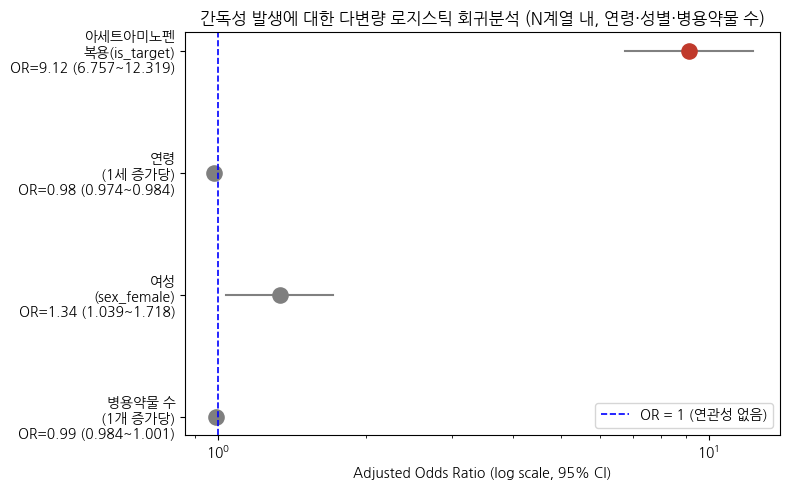

In [15]:
# 위 로지스틱 회귀 결과 forest plot
or_vals = np.exp(model2.params)
ci = np.exp(model2.conf_int())

variables = ['아세트아미노펜\n복용(is_target)', '연령\n(1세 증가당)', '여성\n(sex_female)', '병용약물 수\n(1개 증가당)']
keys = ['is_target', 'age_num', 'sex_female', 'num_drugs']
ORs = [round(or_vals[k],2) for k in keys]
ci_lows = [round(ci.loc[k,0],3) for k in keys]
ci_highs = [round(ci.loc[k,1],3) for k in keys]
colors = ['#c0392b', '#7f7f7f', '#7f7f7f', '#7f7f7f']

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(variables))[::-1]
for i, (or_val, lo, hi, c) in enumerate(zip(ORs, ci_lows, ci_highs, colors)):
    y = y_pos[i]
    ax.plot([lo, hi], [y, y], color='gray', linewidth=1.5, zorder=1)
    ax.scatter([or_val], [y], color=c, s=120, zorder=2)

ax.axvline(1, color='blue', linestyle='--', linewidth=1.2, label='OR = 1 (연관성 없음)')
ax.set_xscale('log')
ax.set_yticks(y_pos)
ax.set_yticklabels([f'{v}\nOR={o} ({l}~{h})' for v,o,l,h in zip(variables, ORs, ci_lows, ci_highs)])
ax.set_xlabel('Adjusted Odds Ratio (log scale, 95% CI)')
ax.set_title('간독성 발생에 대한 다변량 로지스틱 회귀분석 (N계열 내, 연령·성별·병용약물 수)', fontsize=12)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

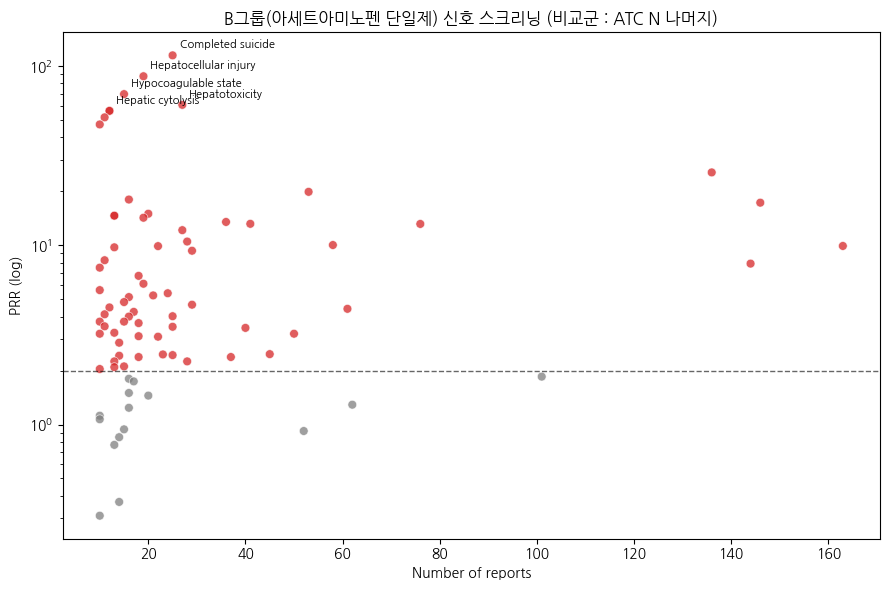

In [16]:
# B그룹 신호 스크리닝 (볼케이노 플롯, 비교군: ATC N 나머지)
fig, ax = plt.subplots(figsize=(9, 6))
colors = np.where(res_b['PRR'] >= 2, '#d62728', '#7f7f7f')
ax.scatter(res_b['a'], res_b['PRR'], s=40, c=colors, alpha=0.75, edgecolors='white', linewidths=0.5)
ax.set_yscale('log'); ax.axhline(2, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Number of reports'); ax.set_ylabel('PRR (log)')
ax.set_title(f'B그룹(아세트아미노펜 단일제) 신호 스크리닝 (비교군 : ATC N 나머지)')
top5 = res_b.head(5)
for _, r in top5.iterrows():
    ax.annotate(r['reaction'], (r['a'], r['PRR']), fontsize=8, xytext=(5, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

In [17]:
# 다변량 로지스틱 회귀: 회복 여부 (연령·성별·병용약물 수 통제)
model_data3 = n_only[['patient_recovered', 'is_target', 'age_num', 'sex_female', 'num_drugs']].dropna().copy()
model_data3['patient_recovered'] = model_data3['patient_recovered'].astype(int)
model3 = smf.logit('patient_recovered ~ is_target + age_num + sex_female + num_drugs', data=model_data3).fit()
print(model3.summary())

Optimization terminated successfully.
         Current function value: 0.625956
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:      patient_recovered   No. Observations:                 3464
Model:                          Logit   Df Residuals:                     3459
Method:                           MLE   Df Model:                            4
Date:                Tue, 14 Jul 2026   Pseudo R-squ.:                 0.01974
Time:                        07:22:32   Log-Likelihood:                -2168.3
converged:                       True   LL-Null:                       -2212.0
Covariance Type:            nonrobust   LLR p-value:                 4.856e-18
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2380      0.129     -1.851      0.064      -0.490       0.014
is_target      0.3341      0.

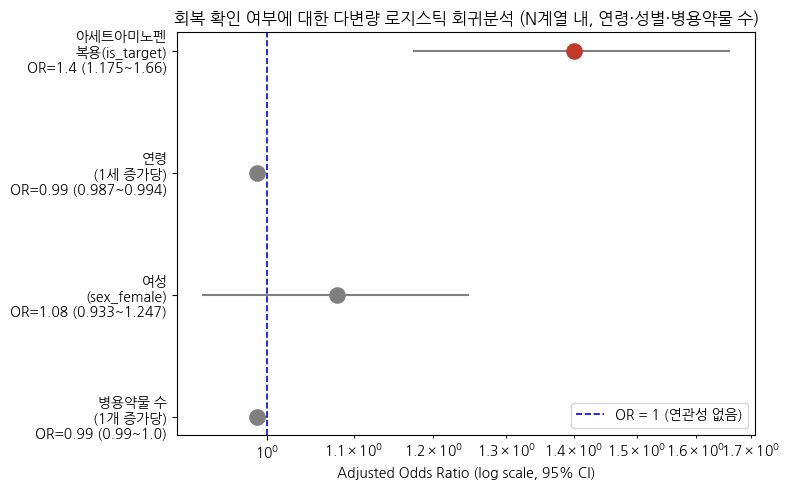

In [18]:
# 위 로지스틱 회귀 결과 forest plot
or_vals3 = np.exp(model3.params)
ci3 = np.exp(model3.conf_int())

variables3 = ['아세트아미노펜\n복용(is_target)', '연령\n(1세 증가당)', '여성\n(sex_female)', '병용약물 수\n(1개 증가당)']
keys3 = ['is_target', 'age_num', 'sex_female', 'num_drugs']
ORs3 = [round(or_vals3[k],2) for k in keys3]
ci_lows3 = [round(ci3.loc[k,0],3) for k in keys3]
ci_highs3 = [round(ci3.loc[k,1],3) for k in keys3]
colors3 = ['#c0392b', '#7f7f7f', '#7f7f7f', '#7f7f7f']

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(variables3))[::-1]
for i, (or_val, lo, hi, c) in enumerate(zip(ORs3, ci_lows3, ci_highs3, colors3)):
    y = y_pos[i]
    ax.plot([lo, hi], [y, y], color='gray', linewidth=1.5, zorder=1)
    ax.scatter([or_val], [y], color=c, s=120, zorder=2)

ax.axvline(1, color='blue', linestyle='--', linewidth=1.2, label='OR = 1 (연관성 없음)')
ax.set_xscale('log')
ax.set_yticks(y_pos)
ax.set_yticklabels([f'{v}\nOR={o} ({l}~{h})' for v,o,l,h in zip(variables3, ORs3, ci_lows3, ci_highs3)])
ax.set_xlabel('Adjusted Odds Ratio (log scale, 95% CI)')
ax.set_title('회복 확인 여부에 대한 다변량 로지스틱 회귀분석 (N계열 내, 연령·성별·병용약물 수)', fontsize=12)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

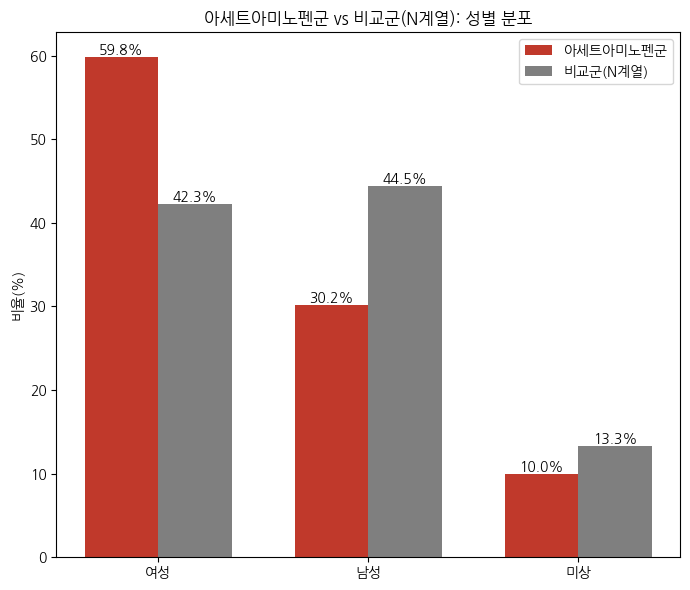

patient_sex  Female  Male  Unknown
row_0                             
False          1265  1331      397
True            796   402      133
Chi-square p-value: 0.000000
Chi-square: 114.30, p-value: 1.51e-25


In [19]:
# 성별 분포: 아세트아미노펜군 vs 비교군(N계열)
sex_b = n_only.loc[n_target_mask, 'patient_sex'].value_counts(normalize=True) * 100
sex_o = n_only.loc[~n_target_mask, 'patient_sex'].value_counts(normalize=True) * 100
categories = ['Female', 'Male', 'Unknown']
b_vals = [sex_b.get(c, 0) for c in categories]
o_vals = [sex_o.get(c, 0) for c in categories]

x = np.arange(len(categories)); width = 0.35
fig, ax = plt.subplots(figsize=(7, 6))
bars1 = ax.bar(x - width/2, b_vals, width, label='아세트아미노펜군', color='#c0392b')
bars2 = ax.bar(x + width/2, o_vals, width, label='비교군(N계열)', color='#7f7f7f')
for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}%', (bar.get_x()+bar.get_width()/2, h), ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(['여성', '남성', '미상'])
ax.set_ylabel('비율(%)')
ax.set_title('아세트아미노펜군 vs 비교군(N계열): 성별 분포')
ax.legend()
plt.tight_layout()
plt.show()

sex_table = pd.crosstab(n_target_mask, n_only['patient_sex'])
chi2, p_sex, dof, exp = chi2_contingency(sex_table)
print(sex_table)
print(f"Chi-square p-value: {p_sex:.6f}")
print(f"Chi-square: {chi2:.2f}, p-value: {p_sex:.2e}")

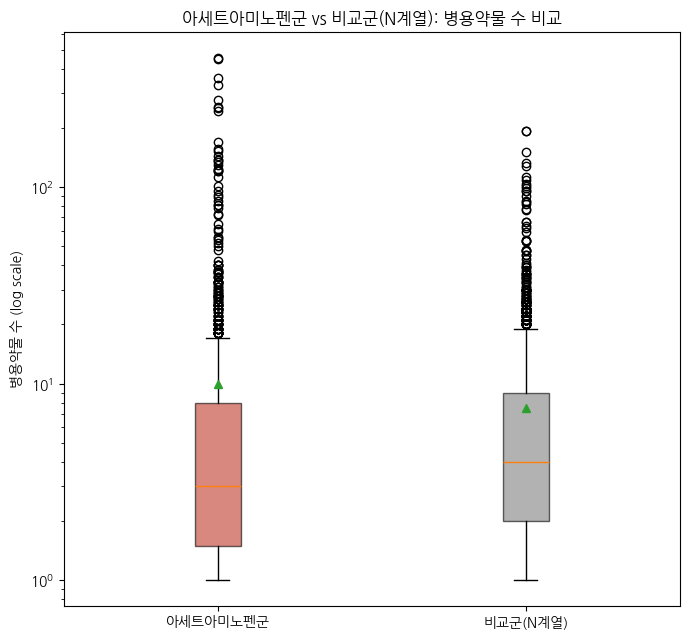

In [20]:
# 병용약물 수 비교: 아세트아미노펜군 vs 비교군(N계열)
drugs_b = n_only.loc[n_target_mask, 'num_drugs'].dropna()
drugs_o = n_only.loc[~n_target_mask, 'num_drugs'].dropna()
u_stat, p_drugs = stats.mannwhitneyu(drugs_b, drugs_o)

fig, ax = plt.subplots(figsize=(7, 6.5))
bp = ax.boxplot([drugs_b, drugs_o], tick_labels=['아세트아미노펜군', '비교군(N계열)'],
                 showmeans=True, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#c0392b', '#7f7f7f']):
    patch.set_facecolor(color); patch.set_alpha(0.6)

ax.set_yscale('log')
ax.set_ylabel('병용약물 수 (log scale)')
ax.set_title(f'아세트아미노펜군 vs 비교군(N계열): 병용약물 수 비교')
plt.tight_layout()
plt.show()

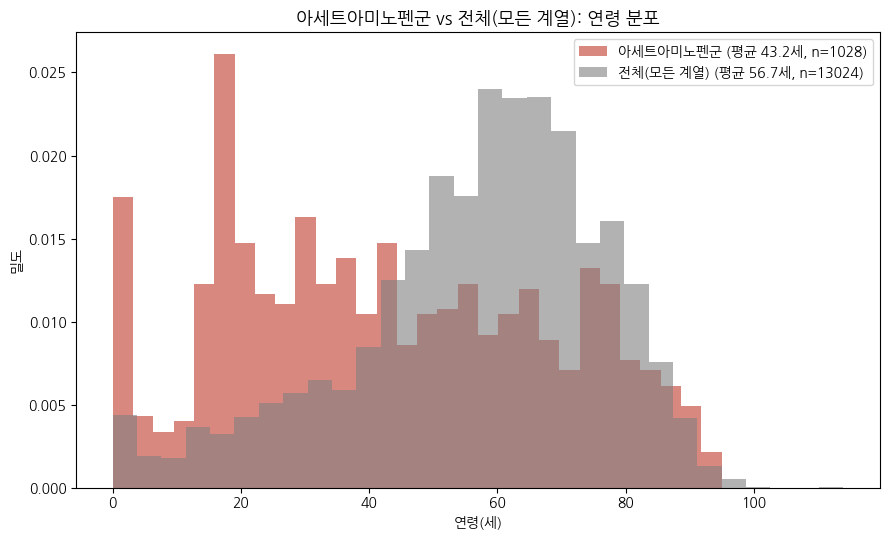

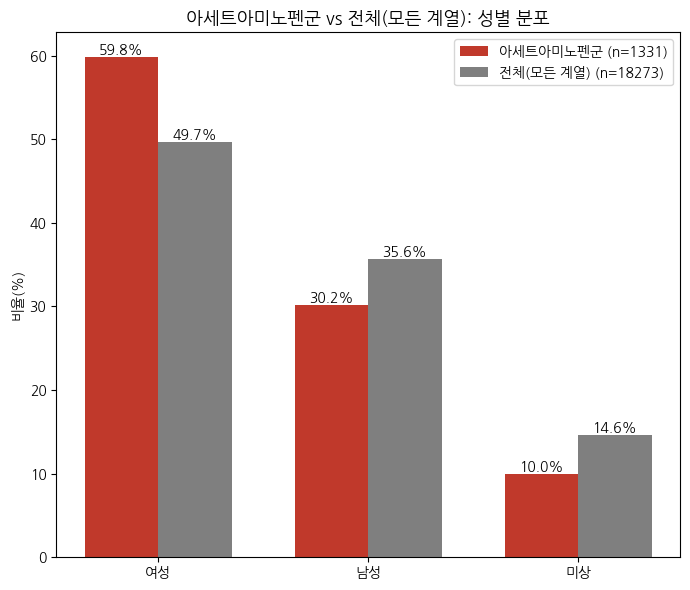


[간독성 vs 전체] 아세트아미노펜군 28.5% (n=379/1331) / 전체 나머지 2.7% (n=459/16942)
OR=14.30 (95% CI 12.29~16.63), Fisher p=4.11e-218


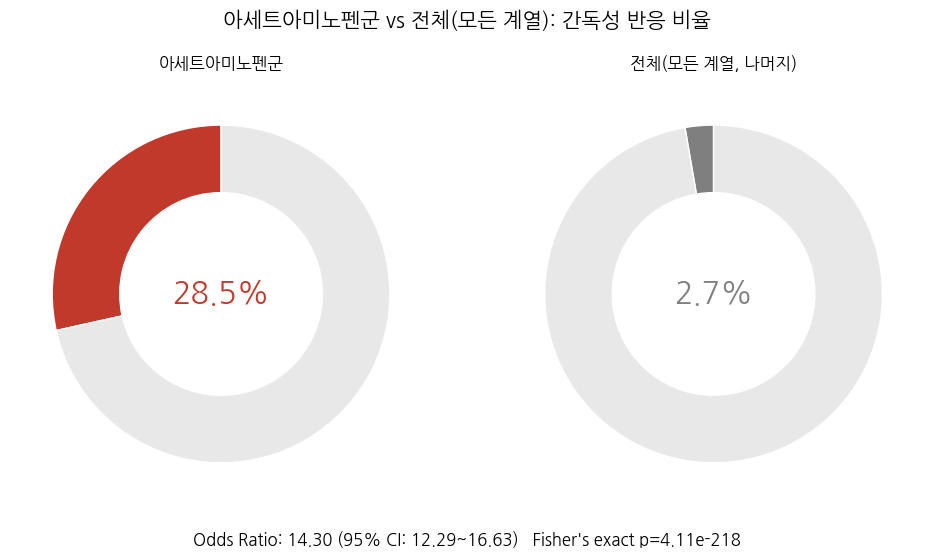

In [21]:
# 아세트아미노펜군 vs 전체(모든 계열): 연령/성별/간독성 비교
n_b = b_mask.sum()

age_b_all = pd.to_numeric(df.loc[b_mask, 'patient_age_years'], errors='coerce').dropna()
age_all = pd.to_numeric(df['patient_age_years'], errors='coerce').dropna()
u_age, p_age = stats.mannwhitneyu(age_b_all, age_all, alternative='two-sided')

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(age_b_all, bins=30, alpha=0.6, color='#c0392b', label=f'아세트아미노펜군 (평균 {age_b_all.mean():.1f}세, n={len(age_b_all)})', density=True)
ax.hist(age_all, bins=30, alpha=0.6, color='#7f7f7f', label=f'전체(모든 계열) (평균 {age_all.mean():.1f}세, n={len(age_all)})', density=True)
ax.set_xlabel('연령(세)')
ax.set_ylabel('밀도')
ax.set_title(f'아세트아미노펜군 vs 전체(모든 계열): 연령 분포', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

sex_b_all = df.loc[b_mask, 'patient_sex'].value_counts(normalize=True) * 100
sex_all = df['patient_sex'].value_counts(normalize=True) * 100
categories = ['Female', 'Male', 'Unknown']
cat_labels = ['여성', '남성', '미상']
b_vals = [sex_b_all.get(c, 0) for c in categories]
all_vals = [sex_all.get(c, 0) for c in categories]

sex_table = pd.crosstab(b_mask, df['patient_sex'])
chi2_sex, p_sex, dof, exp = stats.chi2_contingency(sex_table)

x = np.arange(len(categories)); width = 0.35
fig, ax = plt.subplots(figsize=(7, 6))
bars1 = ax.bar(x - width/2, b_vals, width, label=f'아세트아미노펜군 (n={n_b})', color='#c0392b')
bars2 = ax.bar(x + width/2, all_vals, width, label=f'전체(모든 계열) (n={N_total})', color='#7f7f7f')
for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}%', (bar.get_x()+bar.get_width()/2, h), ha='center', va='bottom', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(cat_labels)
ax.set_ylabel('비율(%)')
ax.set_title(f'아세트아미노펜군 vs 전체(모든 계열): 성별 분포', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

df['is_liver'] = df['reactions'].astype(str).str.lower().apply(lambda r: any(kw in r for kw in liver_keywords))
a = df.loc[b_mask, 'is_liver'].sum()
b_ = n_b - a
c = df.loc[~b_mask, 'is_liver'].sum()
d = (N_total - n_b) - c

_, p_liver = stats.fisher_exact([[a, b_], [c, d]])
OR = (a*d) / (b_*c)
se = np.sqrt(1/a + 1/b_ + 1/c + 1/d)
ci_low = np.exp(np.log(OR) - 1.96*se)
ci_high = np.exp(np.log(OR) + 1.96*se)

print(f"\n[간독성 vs 전체] 아세트아미노펜군 {a/n_b*100:.1f}% (n={a}/{n_b}) / 전체 나머지 {c/(N_total-n_b)*100:.1f}% (n={c}/{N_total-n_b})")
print(f"OR={OR:.2f} (95% CI {ci_low:.2f}~{ci_high:.2f}), Fisher p={p_liver:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
pct_b = a/n_b*100
pct_o = c/(N_total-n_b)*100
groups = [('아세트아미노펜군', pct_b, '#c0392b'), ('전체(모든 계열, 나머지)', pct_o, '#7f7f7f')]
for ax, (label, pct, color) in zip(axes, groups):
    ax.pie([pct, 100-pct], colors=[color, '#e8e8e8'], startangle=90, wedgeprops={'width': 0.4, 'edgecolor': 'white'})
    ax.text(0, 0, f'{pct:.1f}%', ha='center', va='center', fontsize=22, fontweight='bold', color=color)
    ax.set_title(label, fontsize=12, pad=10)
fig.suptitle('아세트아미노펜군 vs 전체(모든 계열): 간독성 반응 비율', fontsize=15, y=1.02)
fig.text(0.5, -0.05, f"Odds Ratio: {OR:.2f} (95% CI: {ci_low:.2f}~{ci_high:.2f})   Fisher's exact p={p_liver:.2e}",
         ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

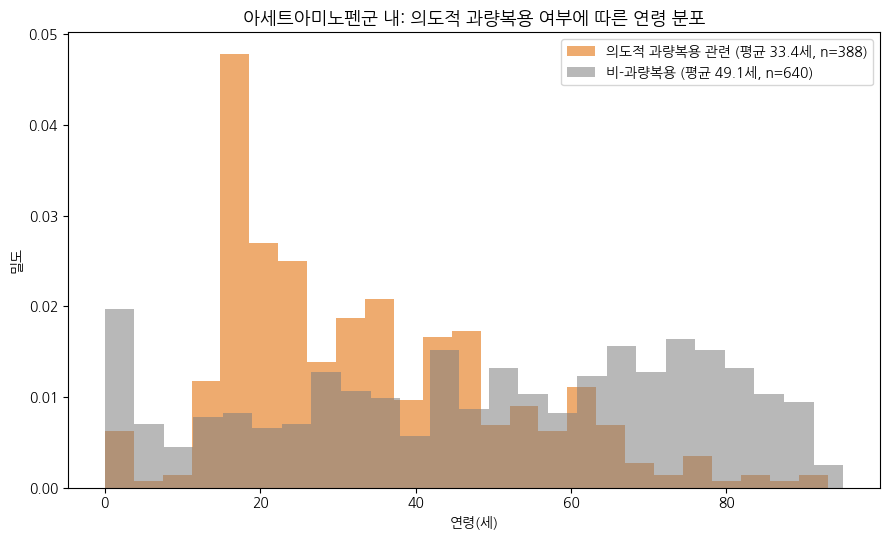

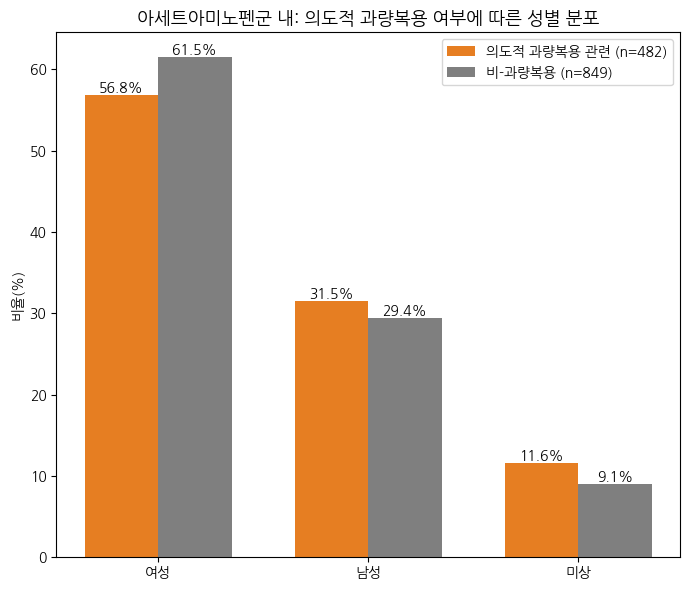

/tmp/ipykernel_682/4223812613.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_od_rate = b_df.groupby('age_group2')['is_overdose'].mean() * 100
/tmp/ipykernel_682/4223812613.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_od_n = b_df.groupby('age_group2').size()


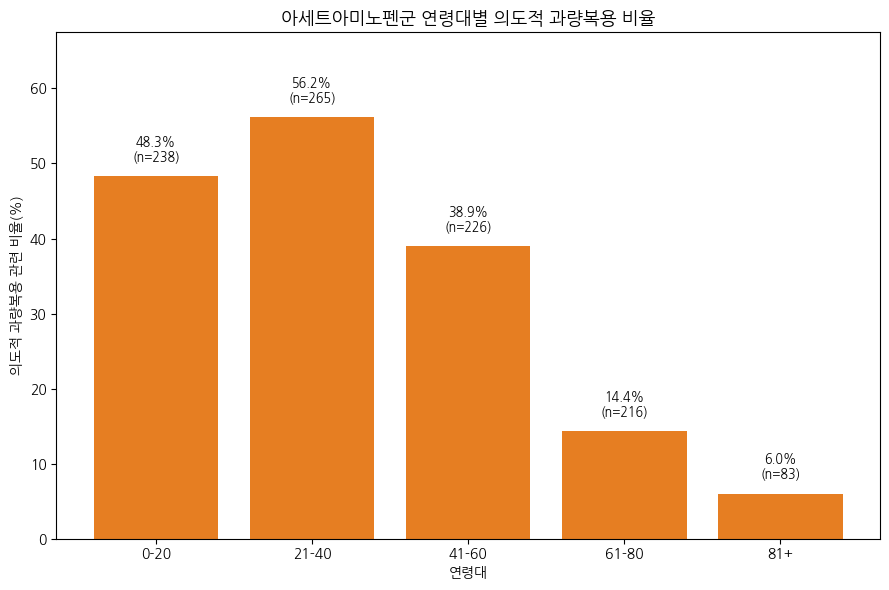

In [22]:
# 아세트아미노펜군 내: 의도적 과량복용 여부에 따른 연령/성별/연령대별 비율
b_df['is_overdose'] = b_df['reactions'].astype(str).str.lower().apply(
    lambda r: any(kw in r for kw in overdose_keywords))
n_od = b_df['is_overdose'].sum()
n_non_od = n_b - n_od

age_od = pd.to_numeric(b_df.loc[b_df['is_overdose'], 'patient_age_years'], errors='coerce').dropna()
age_non = pd.to_numeric(b_df.loc[~b_df['is_overdose'], 'patient_age_years'], errors='coerce').dropna()
u_age, p_age = stats.mannwhitneyu(age_od, age_non, alternative='two-sided')

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(age_od, bins=25, alpha=0.65, color='#e67e22', label=f'의도적 과량복용 관련 (평균 {age_od.mean():.1f}세, n={len(age_od)})', density=True)
ax.hist(age_non, bins=25, alpha=0.55, color='#7f7f7f', label=f'비-과량복용 (평균 {age_non.mean():.1f}세, n={len(age_non)})', density=True)
ax.set_xlabel('연령(세)')
ax.set_ylabel('밀도')
ax.set_title(f'아세트아미노펜군 내: 의도적 과량복용 여부에 따른 연령 분포', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

sex_od = b_df.loc[b_df['is_overdose'], 'patient_sex'].value_counts(normalize=True) * 100
sex_non = b_df.loc[~b_df['is_overdose'], 'patient_sex'].value_counts(normalize=True) * 100
categories = ['Female', 'Male', 'Unknown']
cat_labels = ['여성', '남성', '미상']
od_vals = [sex_od.get(c, 0) for c in categories]
non_vals = [sex_non.get(c, 0) for c in categories]

sex_table = pd.crosstab(b_df['is_overdose'], b_df['patient_sex'])
chi2_sex, p_sex, dof, exp = stats.chi2_contingency(sex_table)

x = np.arange(len(categories)); width = 0.35
fig, ax = plt.subplots(figsize=(7, 6))
bars1 = ax.bar(x - width/2, od_vals, width, label=f'의도적 과량복용 관련 (n={n_od})', color='#e67e22')
bars2 = ax.bar(x + width/2, non_vals, width, label=f'비-과량복용 (n={n_non_od})', color='#7f7f7f')
for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}%', (bar.get_x()+bar.get_width()/2, h), ha='center', va='bottom', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(cat_labels)
ax.set_ylabel('비율(%)')
ax.set_title(f'아세트아미노펜군 내: 의도적 과량복용 여부에 따른 성별 분포', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

b_df['age_num'] = pd.to_numeric(b_df['patient_age_years'], errors='coerce')
b_df['age_group2'] = pd.cut(b_df['age_num'], bins=[0,20,40,60,80,120], labels=['0-20','21-40','41-60','61-80','81+'])
age_od_rate = b_df.groupby('age_group2')['is_overdose'].mean() * 100
age_od_n = b_df.groupby('age_group2').size()

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(age_od_rate.index.astype(str), age_od_rate.values, color='#e67e22')
for bar, v, n in zip(bars, age_od_rate.values, age_od_n.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+2, f'{v:.1f}%\n(n={n})', ha='center', fontsize=9)
ax.set_xlabel('연령대')
ax.set_ylabel('의도적 과량복용 관련 비율(%)')
ax.set_title('아세트아미노펜군 연령대별 의도적 과량복용 비율', fontsize=13)
ax.set_ylim(0, max(age_od_rate.values) * 1.2)
plt.tight_layout()
plt.show()

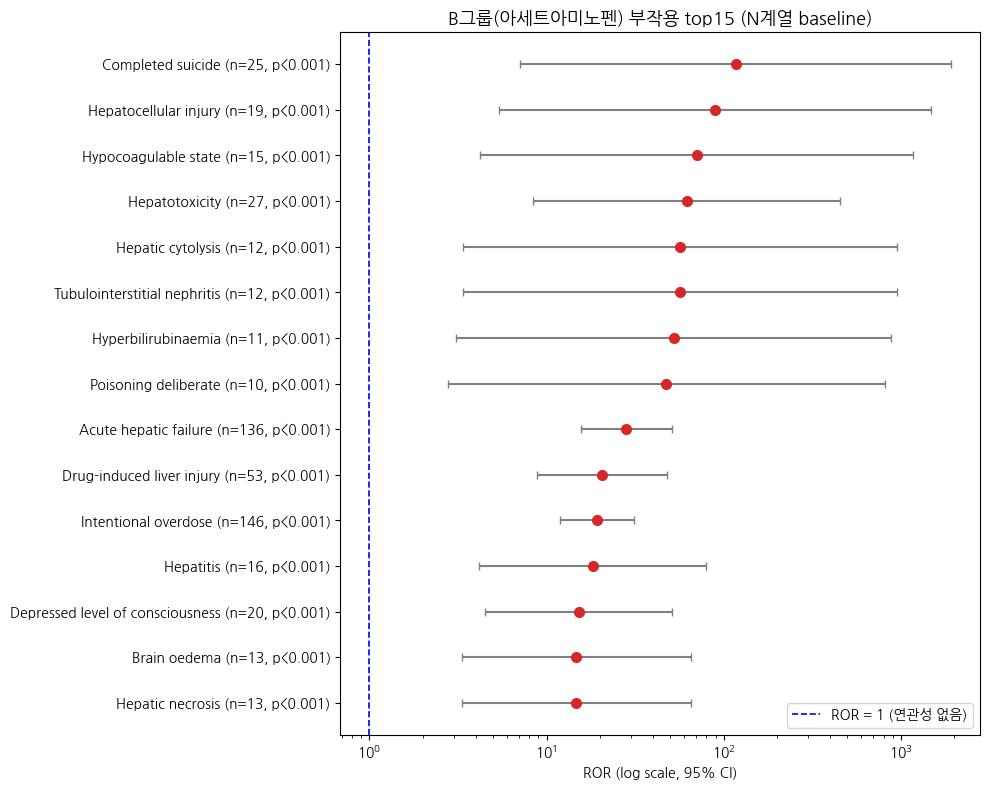

In [23]:
# B그룹 부작용 top15 forest plot (ROR 기준, N계열 baseline)
top15 = res_b.sort_values('ROR', ascending=False).head(15).iloc[::-1]

def p_label(p):
    return 'p<0.001' if p < 0.001 else f'p={p:.3f}'

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(top15))
err_low = top15['ROR'] - top15['ROR_CI_low']
err_high = top15['ROR_CI_high'] - top15['ROR']
ax.errorbar(top15['ROR'], y_pos, xerr=[err_low, err_high], fmt='o', color='#d62728',
            ecolor='gray', capsize=3, markersize=7)
ax.axvline(1, color='blue', linestyle='--', linewidth=1.2, label='ROR = 1 (연관성 없음)')
ax.set_xscale('log')
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{r} (n={a}, {p_label(p)})" for r, a, p in zip(top15['reaction'], top15['a'], top15['p_value'])])
ax.set_xlabel('ROR (log scale, 95% CI)')
ax.set_title('B그룹(아세트아미노펜) 부작용 top15 (N계열 baseline)', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

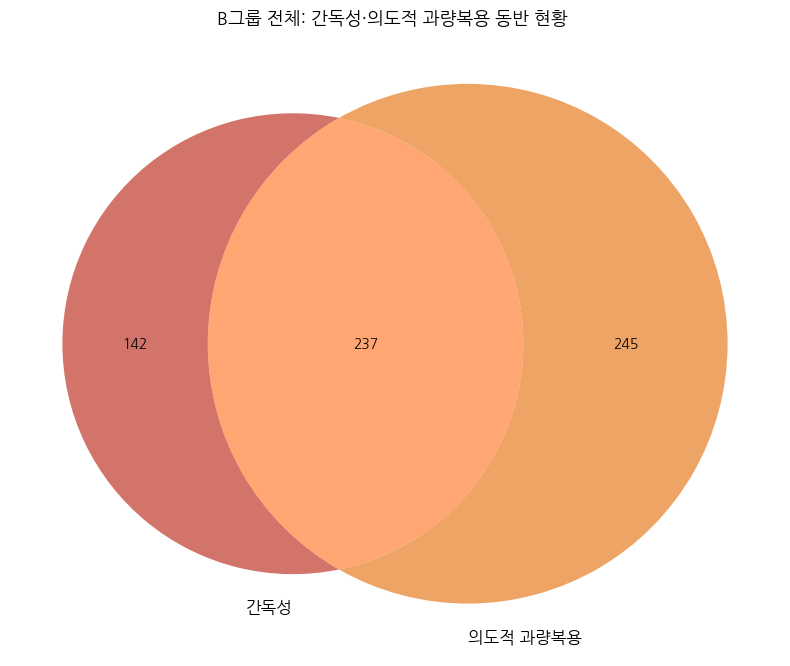

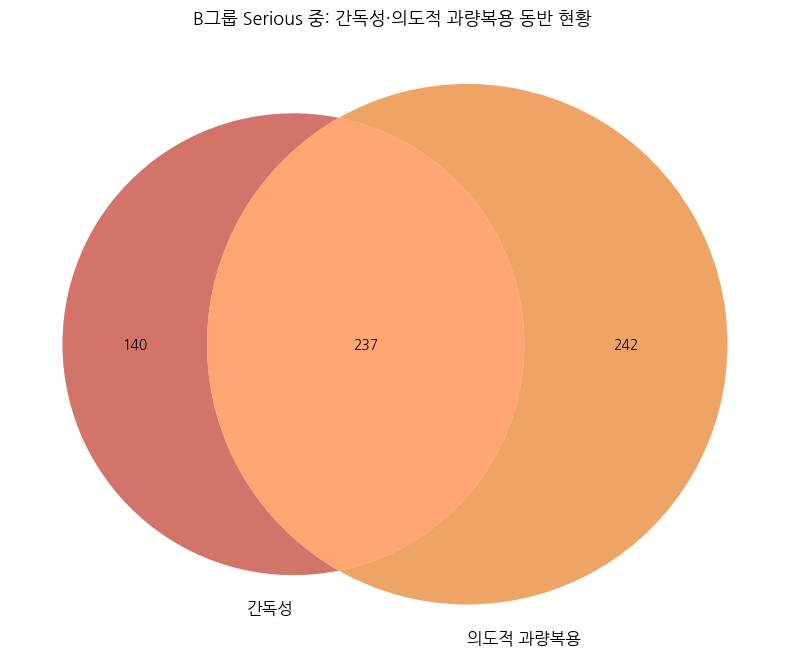

In [24]:
# B그룹: 간독성 x 의도적 과량복용 동반 현황 (벤 다이어그램, 전체 vs Serious)
b_df['is_overdose'] = b_df['reactions'].astype(str).str.lower().apply(lambda r: any(kw in r for kw in overdose_keywords))

def counts(sub):
    only_liver = ((sub['is_liver']) & (~sub['is_overdose'])).sum()
    only_od = ((~sub['is_liver']) & (sub['is_overdose'])).sum()
    both = ((sub['is_liver']) & (sub['is_overdose'])).sum()
    neither = ((~sub['is_liver']) & (~sub['is_overdose'])).sum()
    return only_liver, only_od, both, neither

ol, oo, bo, ne = counts(b_df)
fig, ax = plt.subplots(figsize=(8, 7))
venn2(subsets=(ol, oo, bo), set_labels=('간독성', '의도적 과량복용'), ax=ax,
      set_colors=('#c0392b', '#e67e22'), alpha=0.7)
ax.set_title(f'B그룹 전체: 간독성·의도적 과량복용 동반 현황 ', fontsize=13)
plt.tight_layout()
plt.show()

serious_df = b_df[b_df['serious'] == 'Yes'].copy()
ol_s, oo_s, bo_s, ne_s = counts(serious_df)
fig, ax = plt.subplots(figsize=(8, 7))
venn2(subsets=(ol_s, oo_s, bo_s), set_labels=('간독성', '의도적 과량복용'), ax=ax,
      set_colors=('#c0392b', '#e67e22'), alpha=0.7)
ax.set_title(f'B그룹 Serious 중: 간독성·의도적 과량복용 동반 현황 ', fontsize=13)
plt.tight_layout()
plt.show()

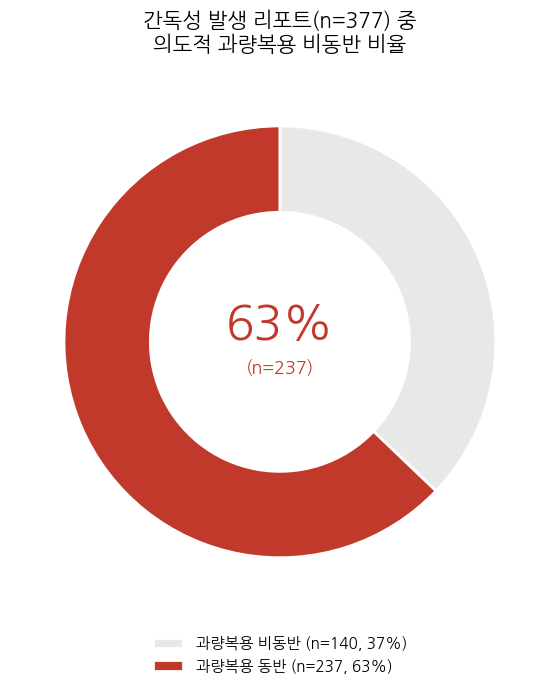

In [25]:
# 간독성 발생 리포트 중 의도적 과량복용 비동반 비율 (원본 수치 그대로 사용)
n_total = 377
n_od = 237
n_non = 140
pct_od = n_od / n_total * 100
pct_non = n_non / n_total * 100

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts = ax.pie(
    [n_non, n_od], colors=['#e8e8e8','#c0392b'], startangle=90, counterclock=False,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
)
ax.text(0, 0.08, f'{pct_od:.0f}%', ha='center', va='center', fontsize=34, fontweight='bold', color='#c0392b')
ax.text(0, -0.12, f'(n={n_od})', ha='center', va='center', fontsize=13, color='#c0392b')

ax.set_title(f'간독성 발생 리포트(n={n_total}) 중\n의도적 과량복용 비동반 비율', fontsize=15, fontweight='bold', pad=15)

legend_labels = [f'과량복용 비동반 (n={n_non}, {pct_non:.0f}%)', f'과량복용 동반 (n={n_od}, {pct_od:.0f}%)']
ax.legend([wedges[0], wedges[1]], legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.02), fontsize=11, frameon=False)
plt.tight_layout()
plt.show()